In [1]:
import pandas as pd
import numpy as np

In [2]:
!pip -q install pyarrow fastparquet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:00


In [3]:
path = "secret"
df = pd.read_parquet(path)
df.shape, df.head()

((135924, 45),
       loan_id   product_id  customer_id origination_date  principal_amount  \
 0  8589961901  CONSO_PERSO        44952       2021-11-17      26970.374025   
 1  8589941872  CONSO_PERSO        30298       2023-09-30      20657.534354   
 2  8589955992   CONSO_AUTO        40618       2019-04-19       3839.040670   
 3  8589963180  CONSO_PERSO        45916       2024-11-15       8601.656795   
 4  8589936753   CONSO_AUTO        26562       2020-03-29       3820.040382   
 
    maturity_months  interest_rate_annual  age age_bucket  annual_income  ...  \
 0               37              0.049794   21      18-25   45057.868372  ...   
 1               18              0.047171   56      41-60   82359.768870  ...   
 2               62              0.040524   38      26-40   45276.664880  ...   
 3               25              0.042488   34      26-40   63915.201074  ...   
 4               46              0.039263   31      26-40   21400.278361  ...   
 
   default_flag defau

In [4]:
df.head(5)

,loan_id,product_id,customer_id,origination_date,principal_amount,maturity_months,interest_rate_annual,age,age_bucket,annual_income,...,default_flag,default_date,months_since_origination_at_default,default_reason,vintage_year,exposure_bucket,interest_rate_bucket,term_bucket,loan_to_income,high_risk_flag
0,8589961901,CONSO_PERSO,44952,2021-11-17,26970.374025,37,0.049794,21,18-25,45057.868372,...,NaN,None,NaN,None,2021,20K-100K,3%-6%,36-84m,0.598572,0
1,8589941872,CONSO_PERSO,30298,2023-09-30,20657.534354,18,0.047171,56,41-60,82359.768870,...,NaN,None,NaN,None,2023,20K-100K,3%-6%,12-36m,0.250821,0
2,8589955992,CONSO_AUTO,40618,2019-04-19,3839.040670,62,0.040524,38,26-40,45276.664880,...,NaN,None,NaN,None,2019,<5K,3%-6%,36-84m,0.084791,0
3,8589963180,CONSO_PERSO,45916,2024-11-15,8601.656795,25,0.042488,34,26-40,63915.201074,...,NaN,None,NaN,None,2024,5K-20K,3%-6%,12-36m,0.134579,0
4,8589936753,CONSO_AUTO,26562,2020-03-29,3820.040382,46,0.039263,31,26-40,21400.278361,...,NaN,None,NaN,None,2020,<5K,3%-6%,36-84m,0.178504,0


In [5]:
list(df.columns)

['loan_id',
 'product_id',
 'customer_id',
 'origination_date',
 'principal_amount',
 'maturity_months',
 'interest_rate_annual',
 'age',
 'age_bucket',
 'annual_income',
 'income_bucket',
 'employment_status',
 'nb_past_loans',
 'has_previous_defaults',
 'avg_past_arrears',
 'arrears_bucket',
 'credit_score',
 'credit_score_bucket',
 'risk_score_raw',
 'product_name',
 'product_type',
 'regulatory_portfolio',
 'ifrs9_segment',
 'interest_rate_type',
 'base_margin_bp',
 'typical_maturity_min_months',
 'typical_maturity_max_months',
 'typical_amount_min',
 'typical_amount_max',
 'collateral_type',
 'secured_flag',
 'base_lgd_level',
 'lgd_sensitivity_to_macro',
 'ead_profile',
 'ccf_baseline',
 'default_flag',
 'default_date',
 'months_since_origination_at_default',
 'default_reason',
 'vintage_year',
 'exposure_bucket',
 'interest_rate_bucket',
 'term_bucket',
 'loan_to_income',
 'high_risk_flag']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135924 entries, 0 to 135923
Data columns (total 45 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_id                              135924 non-null  int64  
 1   product_id                           135924 non-null  object 
 2   customer_id                          135924 non-null  int32  
 3   origination_date                     135924 non-null  object 
 4   principal_amount                     135924 non-null  float64
 5   maturity_months                      135924 non-null  int32  
 6   interest_rate_annual                 135924 non-null  float64
 7   age                                  135924 non-null  int32  
 8   age_bucket                           135924 non-null  object 
 9   annual_income                        135924 non-null  float64
 10  income_bucket                        135924 non-null  object 
 11  employment_st

We take a look on the missing values

In [7]:
# missing values
na_count = df.isna().sum()
na_percent = (na_count / len(df)) * 100

na_summary = pd.DataFrame({
    "missing_count": na_count,
    "missing_%": na_percent
}).sort_values("missing_%", ascending=False)

na_summary


,missing_count,missing_%
months_since_origination_at_default,127569,93.853183
default_flag,127569,93.853183
default_date,127569,93.853183
default_reason,127569,93.853183
loan_id,0,0.000000
maturity_months,0,0.000000
interest_rate_annual,0,0.000000
age,0,0.000000
age_bucket,0,0.000000
product_id,0,0.000000


In [8]:
df["default_flag"].unique()


array([nan,  1.])

In [9]:
# To maintain traceability, we create a new cleaned column.

df["default_flag_clean"] = df["default_flag"].apply(
    lambda x: 1 if x == 1 else 0
)

We prepare the database for the modelisation

In [10]:
df['default_flag_clean'].value_counts()

,count
default_flag_clean,
0,127569
1,8355


We check the correlation between the variables

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()


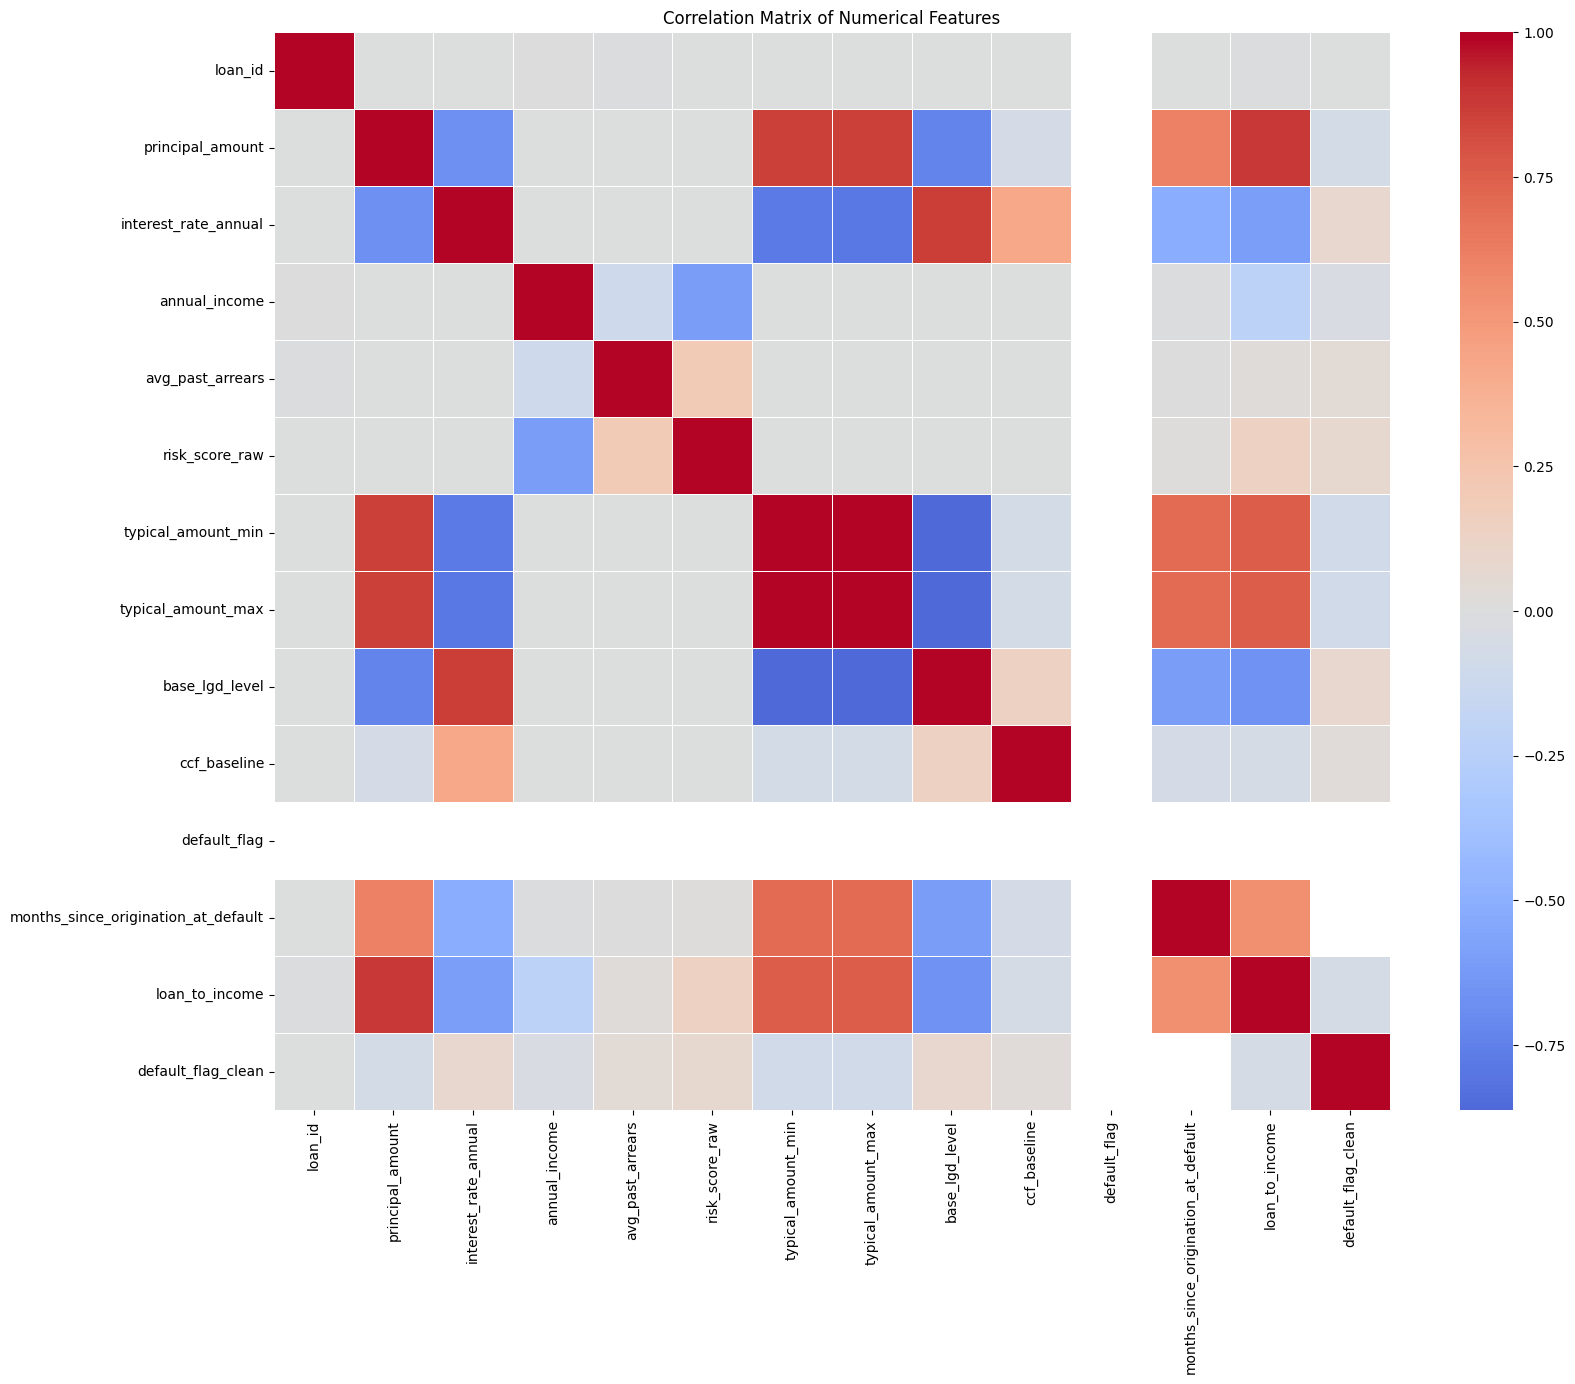

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


The most correlated values

In [14]:

corr_abs = corr_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)
high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.7)
]

high_corr_features


['typical_amount_min',
 'typical_amount_max',
 'base_lgd_level',
 'months_since_origination_at_default',
 'loan_to_income']

`months_since_origination_at_default` was removed due to data leakage, and `typical_amount_min/max` were excluded as they reflect product constraints rather than borrower risk.
`loan_to_income` was retained due to its strong economic interpretability and relevance to repayment capacity.


We create the subset that will be used for modelisation. PS : Post-event columns won't be used for the modelisation (example : default_reason)

In [15]:
pd_features = [
    "credit_score",
    "annual_income",
    "loan_to_income",
    "age",
    "maturity_months",
    "interest_rate_annual",
    "product_type",
    "income_bucket",
    "credit_score_bucket",
    "arrears_bucket",
    "has_previous_defaults"
]

X = df[pd_features]
y = df["default_flag_clean"]


## **Credit Risk Modeling – Probability of Default (PD)**


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [17]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


In [18]:
baseline_default_rate = y_train.mean()
baseline_default_rate


np.float64(0.061463435141782104)

In [ ]:
# 6.14 persons are in default


The baseline default rate corresponds to the average default rate observed in the training set.\
It represents the simplest possible benchmark: predicting the majority class (non-default) for all observations.\
Any predictive model should outperform this baseline to demonstrate added value beyond naive classification.


### **Logistic Regression model**

Logistic regression was selected as the primary modeling approach due to its strong alignment with credit risk management practices.
The objective of this project is not predictive optimization, but the construction of an interpretable and stable probability of default signal that can support business decisions.

Logistic regression provides transparent coefficients, allows direct interpretation of risk drivers, and produces calibrated default probabilities.
These properties make it a standard choice for PD modeling in banking and regulatory contexts.

More complex models could potentially improve predictive performance, but were deliberately not prioritized to preserve explainability and decision-oriented analysis.


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=2000)

In [20]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
auc


np.float64(0.6329961926156812)

The model achieves a ROC–AUC score of 0.63 on the test set, indicating a limited but meaningful discriminatory power. The model performs better than random classification and has a 63% probability of ranking a positive instance higher than a negative one. This result suggests that the model captures part of the signal in the data but leaves room for improvement.

In [21]:
from sklearn.metrics import classification_report

y_pred = (y_pred_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.54      0.69     38271
           1       0.08      0.64      0.15      2507

    accuracy                           0.54     40778
   macro avg       0.52      0.59      0.42     40778
weighted avg       0.90      0.54      0.65     40778



In [22]:
y_pred_proba.min(), y_pred_proba.max(), y_pred_proba.mean()


(np.float64(0.19692902222727668),
 np.float64(0.8682000106493338),
 np.float64(0.4707022997556356))

Although the model shows a moderate discriminatory power (ROC–AUC = 0.63), the default classification threshold of 0.5 leads to poor performance due to class imbalance. Most observations are classified as default, resulting in high recall but very low precision.

In [24]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_threshold = thresholds[np.argmax(f1_scores)]
best_threshold


np.float64(0.5700000000000001)

In [25]:
y_pred_opt = (y_pred_proba >= 0.57).astype(int)
print(classification_report(y_test, y_pred_opt))


              precision    recall  f1-score   support

           0       0.95      0.85      0.90     38271
           1       0.11      0.29      0.16      2507

    accuracy                           0.82     40778
   macro avg       0.53      0.57      0.53     40778
weighted avg       0.90      0.82      0.85     40778



In [26]:
# Two classification thresholds were evaluated.
# The first configuration prioritizes recall on the default class, detecting a higher proportion of defaults
# at the cost of many false positives.
# The second configuration favors overall stability and accuracy, with strong performance on non-defaults
# but lower default detection.
# The choice between the two depends on the business objective and risk appetite.


In [27]:
import numpy as np

coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
coef.head(10), coef.tail(10)


(product_type_IMMO               -1.148775
 arrears_bucket_MEDIUM_ARREARS   -0.048666
 credit_score                    -0.001373
 annual_income                    0.000004
 maturity_months                  0.000179
 age                              0.000708
 loan_to_income                   0.010287
 credit_score_bucket_MEDIUM       0.018118
 arrears_bucket_LOW_ARREARS       0.031763
 interest_rate_annual             0.051935
 dtype: float64,
 age                           0.000708
 loan_to_income                0.010287
 credit_score_bucket_MEDIUM    0.018118
 arrears_bucket_LOW_ARREARS    0.031763
 interest_rate_annual          0.051935
 income_bucket_MEDIUM          0.138601
 income_bucket_LOW             0.310340
 credit_score_bucket_LOW       0.378704
 product_type_REVOLVING        0.545645
 has_previous_defaults         0.580756
 dtype: float64)

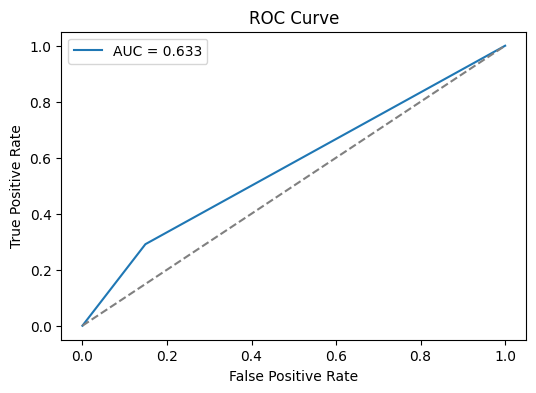

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_opt)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


The ROC curve yields an AUC of 0.633, indicating moderate discriminatory power.\
The model performs better than random but shows limited separation between default and non-default cases.


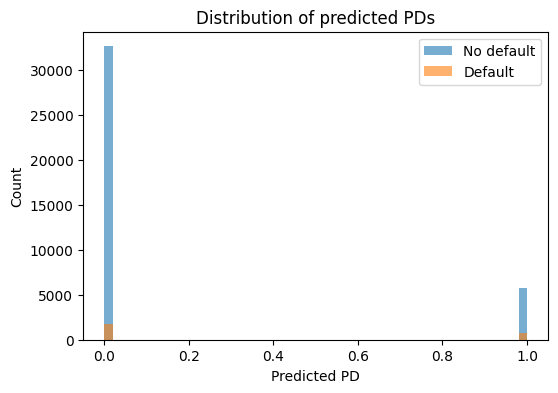

In [29]:
plt.figure(figsize=(6,4))
plt.hist(y_pred_opt[y_test==0], bins=50, alpha=0.6, label="No default")
plt.hist(y_pred_opt[y_test==1], bins=50, alpha=0.6, label="Default")
plt.xlabel("Predicted PD")
plt.ylabel("Count")
plt.title("Distribution of predicted PDs")
plt.legend()
plt.show()


Predicted PDs largely overlap across classes, indicating limited discriminatory power.


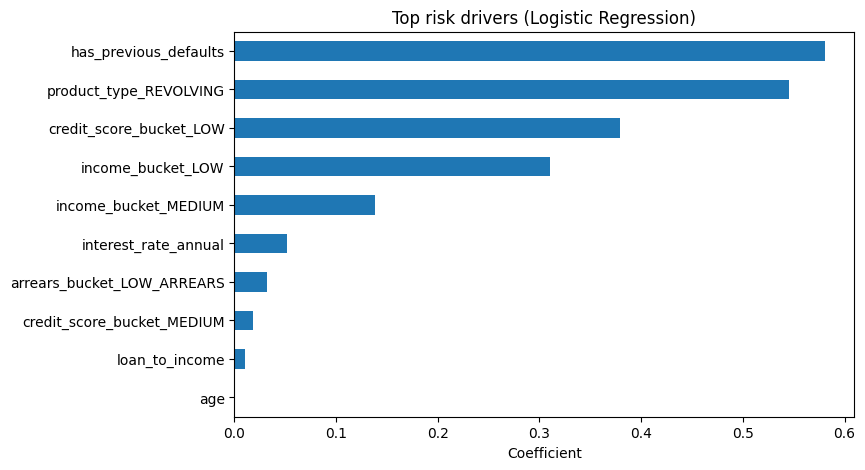

In [30]:
coef_sorted = coef.sort_values()

plt.figure(figsize=(8,5))
coef_sorted.tail(10).plot(kind="barh")
plt.title("Top risk drivers (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()


The logistic regression coefficients indicate that previous defaults and revolving credit products are the strongest drivers of default risk.\
Low credit score and low income buckets also significantly increase default probability, while other variables have a more limited impact.


In [31]:
len(X_test), len(y_pred_proba), len(df), X_test.index.isin(df.index).mean()


(40778, 40778, 135924, np.float64(1.0))

Predicted probabilities are fully aligned with the test set.\
All test observations correspond to valid records in the original dataset, confirming correct data splitting and index consistency.


# Conclusion

A logistic regression model was used as a baseline to model default risk.\
The model shows moderate discriminatory power (ROC–AUC = 0.63), which reflects both the class imbalance and the inherent difficulty of the problem.\
The analysis highlights the importance of threshold selection, as the default 0.5 cutoff leads to suboptimal classification results.\
Key drivers of default risk include previous defaults, credit score, income-related variables, and product characteristics.\
This work provides a solid and interpretable baseline for further model development.
